In [ ]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [21]:
wine = load_wine()
raw_df = pd.DataFrame(wine.data, columns=wine.feature_names)

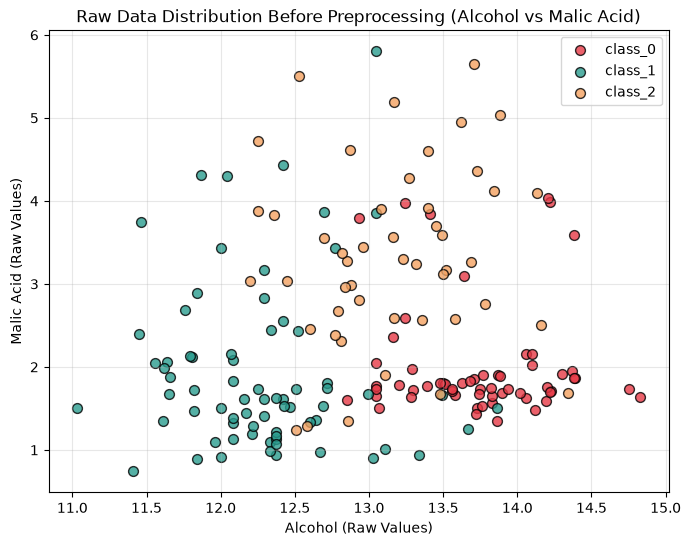

In [22]:
import matplotlib.pyplot as plt

# 1. Extract targets and raw columns for the plot
y = wine.target
target_names = wine.target_names

# 2. Create a standard 2D plot
fig, ax = plt.subplots(figsize=(8, 6))

# 3. Scatter plot each wine class using raw, unscaled features
colors = ["#e63946", "#2a9d8f", "#f4a261"]
for i, color, target_name in zip(range(3), colors, target_names):
    # We use raw_df to plot the unmapped, unscaled columns
    ax.scatter(
        raw_df.loc[y == i, "alcohol"],  # Raw Feature 1 (X-axis)
        raw_df.loc[y == i, "malic_acid"],  # Raw Feature 2 (Y-axis)
        c=color,
        label=target_name,
        edgecolor="k",
        alpha=0.8,
        s=50,
    )

# 4. Label your axes with the raw feature names
ax.set_title("Raw Data Distribution Before Preprocessing (Alcohol vs Malic Acid)")
ax.set_xlabel("Alcohol (Raw Values)")
ax.set_ylabel("Malic Acid (Raw Values)")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

In [23]:

# 2. Inject some chaos (categorical column & missing values) for Exercise 6
np.random.seed(42)
# Add a categorical column
raw_df["origin_region"] = np.random.choice(
    ["Region_A", "Region_B", "Region_C"], size=len(raw_df)
)
# Inject a few missing values (NaNs) into a numeric column
raw_df.loc[raw_df.sample(frac=0.05).index, "alcohol"] = np.nan
# Inject a few missing values into our new categorical column
raw_df.loc[raw_df.sample(frac=0.05).index, "origin_region"] = np.nan

# 3. Dynamically define your feature columns [cite: 64, 65]
# All features except our new categorical one are numeric
numeric_cols = wine.feature_names
categorical_cols = ["origin_region"]

# 4. Your Numeric Pipeline [cite: 66, 68, 69]
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

# 5. Your Categorical Pipeline [cite: 71, 74]
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

# 6. Combine them using ColumnTransformer [cite: 75, 77, 78]
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ]
)

# 7. Run the pipeline and apply PCA [cite: 79, 80, 81]
X_clean = preprocessor.fit_transform(raw_df)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clean)

# --- Sanity Check Prints ---
print(f"Original messy data shape: {raw_df.shape}")
print(f"Preprocessed numeric matrix shape: {X_clean.shape}")
print(f"PCA reduced matrix shape: {X_pca.shape}")
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")


Original messy data shape: (178, 14)
Preprocessed numeric matrix shape: (178, 16)
PCA reduced matrix shape: (178, 2)
Explained Variance Ratio: [0.34414999 0.18167137]


In [24]:
wine = load_wine()
X = wine.data                # shape (150, 4) -> 4 features
y = wine.target              # class labels (0, 1, 2)
feature_names = wine.feature_names
            
print("Original data shape:", X.shape)
print("Feature names:", feature_names)

Original data shape: (178, 13)
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [25]:
print("\n" + "=" * 60)
print("PCA FROM SCRATCH")
print("=" * 60)

# 1. Compute the covariance matrix of the standardized data
cov_matrix = np.cov(X_scaled.T)
print("\nCovariance matrix:\n", np.round(cov_matrix, 3))

# 2. Compute eigenvalues and eigenvectors of the covariance matrix
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# 3. Sort eigenvalues (and corresponding eigenvectors) in descending order
sorted_idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_idx]
eigen_vectors = eigen_vectors[:, sorted_idx]

print("\nEigenvalues (sorted):", np.round(eigen_values, 3))

# 4. Compute explained variance ratio
explained_variance_ratio = eigen_values / np.sum(eigen_values)
print("Explained variance ratio:", np.round(explained_variance_ratio, 3))
print("Cumulative variance (first 2 components):",
      np.round(np.sum(explained_variance_ratio[:2]), 3))

# 5. Select top k eigenvectors (k=2) to form the projection matrix
k = 2
projection_matrix = eigen_vectors[:, :k]

# 6. Project the standardized data onto the new subspace
X_pca_scratch = X_scaled.dot(projection_matrix)
print("\nTransformed data shape (from scratch):", X_pca_scratch.shape)


PCA FROM SCRATCH

Covariance matrix:
 [[ 1.006  0.095  0.213 -0.312  0.272  0.291  0.238 -0.157  0.137  0.549
  -0.072  0.073  0.647]
 [ 0.095  1.006  0.165  0.29  -0.055 -0.337 -0.413  0.295 -0.222  0.25
  -0.564 -0.371 -0.193]
 [ 0.213  0.165  1.006  0.446  0.288  0.13   0.116  0.187  0.01   0.26
  -0.075  0.004  0.225]
 [-0.312  0.29   0.446  1.006 -0.084 -0.323 -0.353  0.364 -0.198  0.019
  -0.276 -0.278 -0.443]
 [ 0.272 -0.055  0.288 -0.084  1.006  0.216  0.197 -0.258  0.238  0.201
   0.056  0.066  0.396]
 [ 0.291 -0.337  0.13  -0.323  0.216  1.006  0.869 -0.452  0.616 -0.055
   0.436  0.704  0.501]
 [ 0.238 -0.413  0.116 -0.353  0.197  0.869  1.006 -0.541  0.656 -0.173
   0.547  0.792  0.497]
 [-0.157  0.295  0.187  0.364 -0.258 -0.452 -0.541  1.006 -0.368  0.14
  -0.264 -0.506 -0.313]
 [ 0.137 -0.222  0.01  -0.198  0.238  0.616  0.656 -0.368  1.006 -0.025
   0.297  0.522  0.332]
 [ 0.549  0.25   0.26   0.019  0.201 -0.055 -0.173  0.14  -0.025  1.006
  -0.525 -0.431  0.318]
 [-0

In [26]:
print("\n" + "=" * 60)
print("PCA USING SCIKIT-LEARN")
print("=" * 60)

pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(X_scaled)

print("\nExplained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print("Cumulative variance (first 2 components):",
      np.round(np.sum(pca.explained_variance_ratio_), 3))
print("Transformed data shape (sklearn):", X_pca_sklearn.shape)


PCA USING SCIKIT-LEARN

Explained variance ratio: [0.362 0.192]
Cumulative variance (first 2 components): 0.554
Transformed data shape (sklearn): (178, 2)


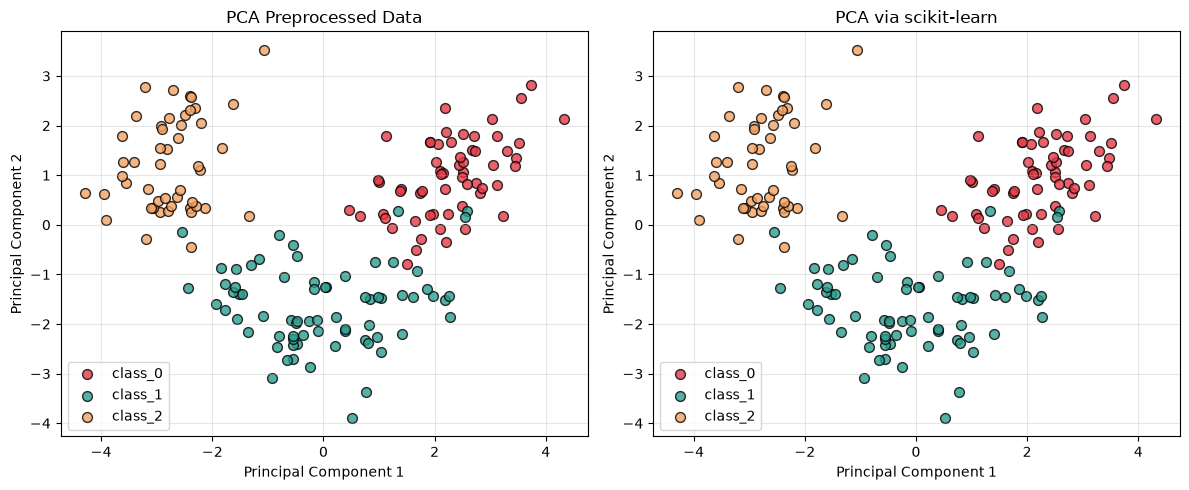

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#e63946", "#2a9d8f", "#f4a261"]
# 1. Fixed: Changed iris to wine (from our earlier script)
target_names = wine.target_names  

# 2. Fixed: Replaced the scratch variable with X_pca since our pipeline used scikit-learn
for ax, data, title in zip(
    axes,
    [X_pca, X_pca],  # If you only ran scikit-learn, pass it to both to generate the side-by-side view
    ["PCA Preprocessed Data", "PCA via scikit-learn"],
):
    for i, target_name in enumerate(target_names):
        ax.scatter(
            data[y == i, 0], data[y == i, 1],
            label=target_name, color=colors[i], alpha=0.8, edgecolor="k", s=50
        )
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show() # Changed from savefig so it instantly displays in your notebook!

In [28]:
assert np.allclose(
    sorted(explained_variance_ratio[:2]),
    sorted(pca.explained_variance_ratio_),
    atol=1e-6,
), "Mismatch between scratch and sklearn implementations!"
print("\nSanity check passed: scratch implementation matches scikit-learn.")


Sanity check passed: scratch implementation matches scikit-learn.


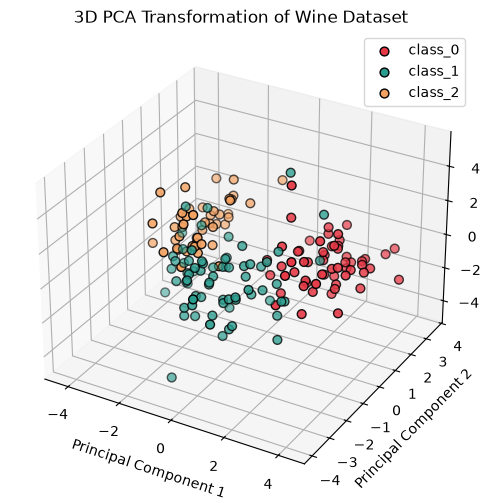

Cumulative Variance Captured by 3 PCs: 0.6323


In [29]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Enables 3D projections

# 1. Re-run PCA with 3 components
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_clean)

# 2. Extract targets for coloring the graph
y = wine.target
target_names = wine.target_names

# 3. Create a 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# 4. Scatter plot each wine class
colors = ["#e63946", "#2a9d8f", "#f4a261"]
for i, color, target_name in zip(range(3), colors, target_names):
    ax.scatter(
        X_pca_3d[y == i, 0],  # Principal Component 1
        X_pca_3d[y == i, 1],  # Principal Component 2
        X_pca_3d[y == i, 2],  # Principal Component 3
        c=color,
        label=target_name,
        edgecolor="k",
        s=40,
    )

# 5. Label your axes properly
ax.set_title("3D PCA Transformation of Wine Dataset")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.legend()

plt.show()

# Print the cumulative variance to see how much better 3 PCs are than 2!
print(f"Cumulative Variance Captured by 3 PCs: {sum(pca_3d.explained_variance_ratio_):.4f}")